# EEP 564 - TinyML - Assignment 2: Network Anomaly Detection

## Introduction

This assignment focuses on network anomaly detection using deep neural networks (DNNs) and model optimization techniques. We will work with the Network Anomaly Dataset, which contains 125,973 samples with 42 features representing normal and attack network connections. The main tasks involve data preprocessing, dimensionality reduction visualization, DNN implementation, dynamic range quantization, and Arduino deployment of the quantized model.

## Preparation

First of all, we will install required packages for data processing, machine learning, and model optimization in this homework:

In [2]:
# Uninstall packages on Google Colab because new versions of TensorFlow has changed some TFLite APIs
#%pip uninstall -y tensorflow tensorflow-model-optimization

# a) Install with CPU only support:
%pip install tensorflow<2.21
# b) Alternatively, with CUDA (GPU) support on Linux:
#%pip install tensorflow[with-cuda]<2.21

%pip install numpy pandas scikit-learn tensorflow-model-optimization tf_keras tqdm

/bin/bash: line 1: 2.21: No such file or directory
  Using cached tensorflow_model_optimization-0.8.1-py2.py3-none-any.whl.metadata (1.1 kB)
  Using cached mock-5.2.0-py3-none-any.whl.metadata (3.1 kB)
Using cached tensorflow_model_optimization-0.8.1-py2.py3-none-any.whl (242 kB)
Using cached mock-5.2.0-py3-none-any.whl (31 kB)


### Note: Resolving `keras.src` Namespace Issue

When using TensorFlow and TensorFlow Model Optimization in Colab, you may encounter a `keras.src` namespace issue, causing incompatibility with `tensorflow_model_optimization.quantization.keras`. To resolve this:

1. Set the `KERAS_BACKEND` environment variable to `tensorflow` before importing TensorFlow.
2. Ensure you are using compatible versions of TensorFlow (`>=2.12`) and TensorFlow Model Optimization.
3. Clone the model using `tensorflow.keras.models.clone_model()` to ensure it aligns with the `tensorflow.keras` namespace.
4. Always restart the runtime and reinstall TensorFlow-related packages to avoid lingering conflicts.

This ensures that all operations use the correct `tensorflow.keras` implementation, avoiding compatibility issues.

In [3]:
import os

# Resolve keras.src namespace issue with TensorFlow Model Optimization
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["TF_USE_LEGACY_KERAS"] = "1"

## Question 1: Dataset Loading and Processing

We start by loading the Network Anomaly Dataset and preparaing it for preprocessing by adding the column titles for the 42 features:

In [4]:
import pandas as pd

# Load the Network Anomaly Dataset with feature names
column_names = [
    "duration", "protocoltype", "service", "flag", "srcbytes", "dstbytes",
    "land", "wrongfragment", "urgent", "hot", "numfailedlogins", "loggedin",
    "numcompromised", "rootshell", "suattempted", "numroot", "numfilecreations",
    "numshells", "numaccessfiles", "numoutboundcmds", "ishostlogin", "isguestlogin",
    "count", "srvcount", "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
    "samesrvrate", "diffsrvrate", "srvdiffhostrate", "dsthostcount", "dsthostsrvcount",
    "dsthostsamesrvrate", "dsthostdiffsrvrate", "dsthostsamesrcportrate",
    "dsthostsrvdiffhostrate", "dsthostserrorrate", "dsthostsrvserrorrate",
    "dsthostrerrorrate", "dsthostsrvrerrorrate", "attack", "lastflag"
]

data = pd.read_csv("Network_anomaly_data.txt", sep=",", names=column_names)

Now, complete the following data preprocessing steps:

1) Drop the `land`, `urgent`, `numfailedlogins`, and `numoutboundcmds` columns from the `DataFrame`.
2) Replace any label that is not named `normal` to `attack` in the attack column.
3) Use `sklearn.preprocessing.LabelEncoder` to convert non-numerical attributes in `protocoltype`, `service`, `flag`, and `attack` columns to numerical values.

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

# Drop low-information columns specified in the assignment.
data = data.drop(columns=["land", "urgent", "numfailedlogins", "numoutboundcmds"])

# Convert all attack types into one binary "attack" class.
data["attack"] = np.where(data["attack"] == "normal", "normal", "attack")

# Encode categorical text columns as integer values for ML models.
label_encoders = {}
for column in ["protocoltype", "service", "flag", "attack"]:
    encoder = LabelEncoder()
    data[column] = encoder.fit_transform(data[column])
    label_encoders[column] = encoder

# Split features and labels, then create train/test sets for later questions.
X = data.drop(columns=["attack"]).values
y = data["attack"].values
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features so each feature contributes on a comparable scale.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Keep class labels for plots/reports and one-hot labels for DNN training.
y_train = y_train_raw
y_test = y_test_raw
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

print("Processed data shape:", data.shape)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Encoded attack labels:", dict(zip(label_encoders["attack"].classes_, label_encoders["attack"].transform(label_encoders["attack"].classes_))))

Processed data shape: (125973, 39)
Training set shape: (100778, 38)
Test set shape: (25195, 38)
Encoded attack labels: {'attack': np.int64(0), 'normal': np.int64(1)}


## Question 2: Dimensionality Reduction for Visualization

Now that we have loaded and processed our dataset, it's time to visualize its data distribution with various techniques. In this part we will try three dimensionality reduction techniques (t-SNE, PCA, KernelPCA) we have already practiced in class. We will plot figures with red marks for attacks and blue marks for normal traffic.

### Task 2a: t-SNE Visualization

Use t-SNE from `sklearn.manifold.TSNE` to visualize **the test set** in 2D with class-based coloring.

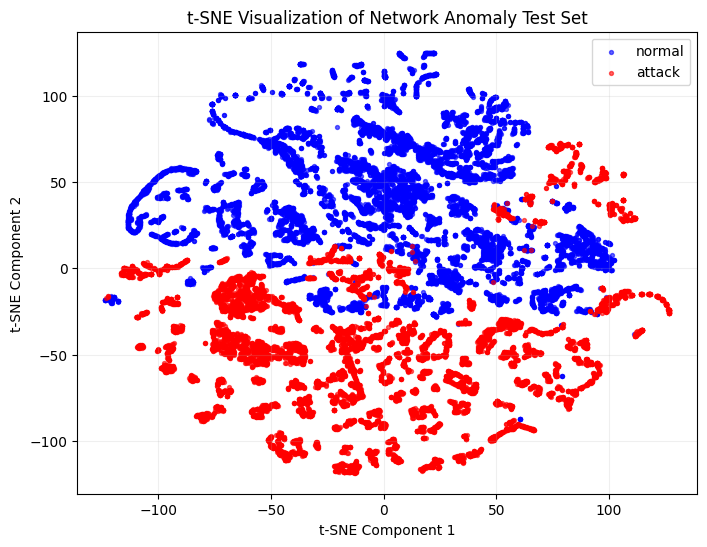

In [6]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Get encoded class values for consistent plot colors.
attack_label = label_encoders["attack"].transform(["attack"])[0]
normal_label = label_encoders["attack"].transform(["normal"])[0]

# Apply t-SNE to project the test set into two dimensions.
tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=42)
X_test_tsne = tsne.fit_transform(X_test)

# Plot attack samples in red and normal samples in blue.
plt.figure(figsize=(8, 6))
plt.scatter(X_test_tsne[y_test == normal_label, 0], X_test_tsne[y_test == normal_label, 1], c="blue", s=8, alpha=0.6, label="normal")
plt.scatter(X_test_tsne[y_test == attack_label, 0], X_test_tsne[y_test == attack_label, 1], c="red", s=8, alpha=0.6, label="attack")
plt.title("t-SNE Visualization of Network Anomaly Test Set")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Task 2b: PCA Visualization

Use PCA from `sklearn.decomposition.PCA` to visualize **the test set** in 2D with class-based coloring. Alternatively you can also use `sklearn.decomposition.IncrementalPCA` to speed up the visualization process.

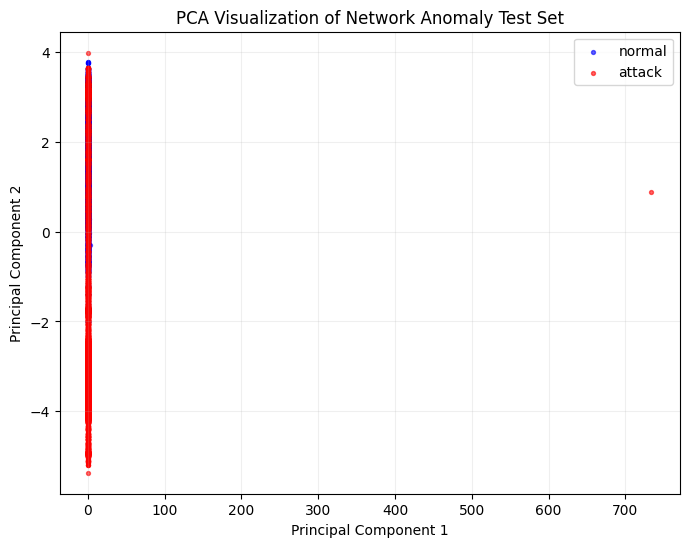

In [7]:
from sklearn.decomposition import PCA

# Apply PCA to project the test set into two dimensions.
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test)

# Plot attack samples in red and normal samples in blue.
plt.figure(figsize=(8, 6))
plt.scatter(X_test_pca[y_test == normal_label, 0], X_test_pca[y_test == normal_label, 1], c="blue", s=8, alpha=0.6, label="normal")
plt.scatter(X_test_pca[y_test == attack_label, 0], X_test_pca[y_test == attack_label, 1], c="red", s=8, alpha=0.6, label="attack")
plt.title("PCA Visualization of Network Anomaly Test Set")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Task 2c: KernelPCA Visualization

Use `KernelPCA` from `sklearn.decomposition.KernelPCA` with RBF kernel to visualize **the test set** in 2D with class-based coloring. You can randomly reduce the amount of data to visualize if this step takes too long, but you **must not** overwrite the original test set if you choose to do so.

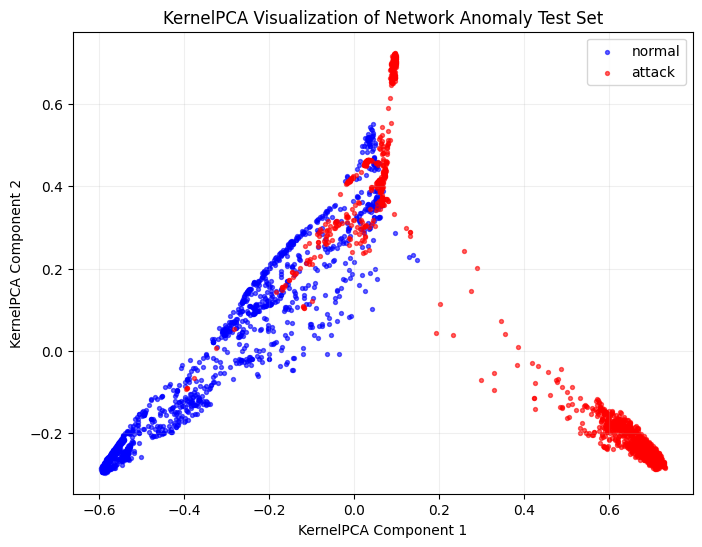

In [8]:
from sklearn.decomposition import KernelPCA

# Randomly sample the test set for KernelPCA without overwriting X_test.
rng = np.random.default_rng(42)
sample_size = min(3000, X_test.shape[0])
sample_indices = rng.choice(X_test.shape[0], size=sample_size, replace=False)
X_test_kpca_input = X_test[sample_indices]
y_test_kpca = y_test[sample_indices]

# Apply RBF KernelPCA to capture nonlinear structure in two dimensions.
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=0.05)
X_test_kpca = kpca.fit_transform(X_test_kpca_input)

# Plot attack samples in red and normal samples in blue.
plt.figure(figsize=(8, 6))
plt.scatter(X_test_kpca[y_test_kpca == normal_label, 0], X_test_kpca[y_test_kpca == normal_label, 1], c="blue", s=8, alpha=0.6, label="normal")
plt.scatter(X_test_kpca[y_test_kpca == attack_label, 0], X_test_kpca[y_test_kpca == attack_label, 1], c="red", s=8, alpha=0.6, label="attack")
plt.title("KernelPCA Visualization of Network Anomaly Test Set")
plt.xlabel("KernelPCA Component 1")
plt.ylabel("KernelPCA Component 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Question 3: Implementing a Deep Neural Network

Alright, it's time to build and train a deep neural network model for anomaly detection. We will create a DNN with an appropriate architecture to classify network traffic as normal or attack, using two output neurons with softmax activation to provide probability distributions over the two classes.

### Task 3a: Define DNN Architecture

To build our network anomaly detection model, we start by defining the architecture of a Sequential neural network. The model should include appropriate hidden layers and an output layer with 2 neurons using softmax activation for binary classification.

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# Define a compact DNN for binary network anomaly classification.
base_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(2, activation="softmax")
])

base_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                2496      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 2)                 34        
                                                                 
Total params: 5138 (20.07 KB)
Trainable params: 5138 (20.07 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Task 3b: Compile and Train Model

Once the model architecture is defined, we compile it with an appropriate optimizer and loss function, then train it on our training data to learn patterns that distinguish between normal and attack network traffic.

In [10]:
# Compile and train the DNN on the training set.
base_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = base_model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
709/709 [==============================] - 5s 4ms/step - loss: 0.0439 - accuracy: 0.9863 - val_loss: 0.0117 - val_accuracy: 0.9964
Epoch 2/10
709/709 [==============================] - 4s 5ms/step - loss: 0.0113 - accuracy: 0.9960 - val_loss: 0.0118 - val_accuracy: 0.9971
Epoch 3/10
709/709 [==============================] - 3s 4ms/step - loss: 0.0079 - accuracy: 0.9970 - val_loss: 0.0093 - val_accuracy: 0.9974
Epoch 4/10
709/709 [==============================] - 3s 4ms/step - loss: 0.0064 - accuracy: 0.9974 - val_loss: 0.0060 - val_accuracy: 0.9986
Epoch 5/10
709/709 [==============================] - 3s 4ms/step - loss: 0.0060 - accuracy: 0.9978 - val_loss: 0.0045 - val_accuracy: 0.9980
Epoch 6/10
709/709 [==============================] - 3s 5ms/step - loss: 0.0052 - accuracy: 0.9980 - val_loss: 0.0054 - val_accuracy: 0.9988
Epoch 7/10
709/709 [==============================] - 3s 4ms/step - loss: 0.0045 - accuracy: 0.9982 - val_loss: 0.0049 - val_accuracy: 0.9986
Epoch 

### Task 3c: Evaluate Model Performance

After training, we evaluate the model's performance on **the unseen test set** using classification metrics to understand how well our model generalizes to new network traffic data.

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict test labels and compare them with the true labels.
test_loss, test_accuracy = base_model.evaluate(X_test, y_test_cat, verbose=0)
y_pred_probs = base_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = label_encoders["attack"].classes_
print(f"Test accuracy: {test_accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

788/788 [==============================] - 1s 2ms/step
Test accuracy: 0.9980
Classification Report:
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11726
      normal       1.00      1.00      1.00     13469

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix:
[[11700    26]
 [   25 13444]]


When all of these steps are done, we save our model weights in file:

In [12]:
# Save the Keras model weights to a HDF5 file
base_model.save("original-model.h5")

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Question 4: Dynamic Range Quantization

Okay, our model is now ready, but we still need to perform a few optimization steps for deployment on resource-constrained devices like our Arduino boards. In this part we will use Dynamic Range Quantzation, which significantly reduces model size while maintaining reasonable accuracy, making deployment feasible on embedded hardware.

### Task 4a: Apply Dynamic Range Quantization

We convert our trained Keras model to TensorFlow Lite (TFLite) format with dynamic range quantization. This process reduces the model's memory footprint significantly, making it suitable for embedded deployment on microcontrollers with limited storage and computational resources.

In [13]:
# Load the trained model
base_model = tf.keras.models.load_model("original-model.h5")

# Convert the Keras model to a dynamically quantized TFLite model.
converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

In [14]:
# Save the quantized model
with open("quantized-model.tflite", 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize("original-model.h5")
quantized_model_size = os.path.getsize("quantized-model.tflite")

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 100.01 KB
Quantized model size: 10.50 KB


### Task 4b: Evaluate Quantized Model

We evaluate the quantized model on the test set to measure the impact of quantization on model accuracy and compare it with the original floating-point model. This helps us understand the trade-off between model compression and prediction performance.

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# Run TFLite inference on each test sample.
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]
tflite_predictions = []

for sample in X_test.astype(np.float32):
    input_data = np.expand_dims(sample, axis=0)

    if input_details["dtype"] != np.float32:
        scale, zero_point = input_details["quantization"]
        input_data = input_data / scale + zero_point
        input_data = input_data.astype(input_details["dtype"])

    interpreter.set_tensor(input_details["index"], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details["index"])

    if output_details["dtype"] != np.float32:
        scale, zero_point = output_details["quantization"]
        output_data = scale * (output_data.astype(np.float32) - zero_point)

    tflite_predictions.append(np.argmax(output_data[0]))

tflite_predictions = np.array(tflite_predictions)

# Compare quantized model predictions with the true labels.
print("Quantized Model Classification Report:")
print(classification_report(y_test, tflite_predictions, target_names=class_names))
print("Quantized Model Confusion Matrix:")
print(confusion_matrix(y_test, tflite_predictions))

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized Model Classification Report:
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     11726
      normal       1.00      1.00      1.00     13469

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Quantized Model Confusion Matrix:
[[11700    26]
 [   24 13445]]


## Converting TFLite Model to C Header

To deploy our quantized model on the Arduino Nano BLE, we need to convert it to a C header file. This allows the microcontroller to load the model directly into its memory and run inference without external dependencies.

In [17]:
# Import c_writer utility for model conversion
import c_writer

# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")


In [18]:
# Write the header file to disk
with open("network_model.h", "w") as f:
    f.write(header_str)

## Generating Test Samples for Arduino Inference

In this final step, we extract test samples and convert them to C-formatted arrays so they can be embedded directly in the Arduino sketch for on-device inference testing.

In [19]:
# Extract and convert the first 5 test samples (indices 0-4)
Xtest_first5 = X_test[:5, :]
print(c_writer.create_array(Xtest_first5, "float", "X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11084689516941944, -2.463272371808293, -0.9917196699795267, 
    0.7496860112013357, -0.007584171097644283, -0.006261883325402098, 
    -0.08981266848602212, -0.09560133107662426, -0.8103630061515018, 
    -0.011603890619592175, -0.037958915085177194, -0.025338529598168607, 
    -0.012330980044623116, -0.02560789062624256, -0.018970493670250374, 
    -0.04047584661572219, -0.0031500633444672952, -0.09801729120291378, 
    3.7336490223468153, 6.671879245744713, -0.6359971671852488, 
    -0.6307379950161282, -0.37423951242198256, -0.37439696879291157, 
    0.7698280493906943, -0.3495293415829906, -0.37571294444937225, 
    0.7354166027139644, 0.3909115440053685, 0.21880031812470738, 
    -0.3331663742093979, 1.5205849685591382, -0.29056711364475607, 
    -0.6383920279802281, -0.6234289502441662, -0.3873113124857261, 
    -0.37609230678856703, -0.648768477722399, -0.1108468951694

In [20]:
# Extract and convert the corresponding labels for the first 5 test samples
ytest_first5 = y_test[:5]
print(c_writer.create_array(ytest_first5, "uint8_t", "y_test"))

const unsigned int y_test_dim1 = 5;

const uint8_t y_test[5] = {
    0, 1, 1, 0, 0
};

